# Phase arithmetic
$
\newcommand{\ket}[1]{\left|#1\right\rangle}
\newcommand{\bra}[1]{\left\langle #1\right|}
\newcommand{\braket}[2]{\left\langle #1 \middle| #2 \right\rangle}
\newcommand{\ketbra}[2]{\left|#1\right\rangle\!\left\langle #2\right|}
$

In [1]:
# allows us to have visibility on our package without installing it in editing mode
import sys;
if ".." not in sys.path: sys.path.append("..")

import itertools
import numpy as np
from qiskit.circuit import QuantumCircuit, Gate
from monaqa2.qiskit.utils_numpy import kron, ketbra, bra, ket
from monaqa2.qiskit.utils_qiskit import get_unitary

import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector


This notebook is dedicated to draft the implementation of the Boltzmann coin unitary, 

$$
B:\ \ket{x}\ket{y}\ket{0}
\mapsto
\ket{x}\ket{y}
\left(
g(x,y)\ket{0}
+
\sqrt{1-g(x,y)^2}\ket{1}
\right).
$$

For finite $a \ge 1$, we use the generalized Glauber acceptance amplitude 

$$g(x,y)=\left(\frac{1}{1+\exp(\beta \, \Delta E(x,y))}\right)^{1/(2a)}$$

where $\Delta E(x,y)=E(y)-E(x)$. The special choice $a=\infty$ denotes the Metropolis-Hastings rule,

$$
g(x,y)=\sqrt{\min(1, e^{-\beta \, \Delta E(x,y)})}.
$$

## Implementation ideas

### Fully fixed-point arithmetic based

A direct implementation of $B$ can be obtained with fully fixed-point arithmetic followed by a controlled rotation. This gives circuits whose depth is polynomial in $n$ and in the target precision, but the arithmetic overhead can be large enough to shift the practical crossover between classical and quantum performance.

### Fully phase-arithmetic based for generalized Glauber acceptance

An alternative is to use the phase-arithmetic approach of [arXiv:2210.14892](https://arxiv.org/pdf/2210.14892). The starting point is to encode the energy difference $\Delta E(x,y)$ as the eigenvalue of a Hamiltonian acting on the pair register $\ket{x}_a\ket{y}_b$.

Let $H$ be the diagonal Ising Hamiltonian on $n$ spins. The delta-energy Hamiltonian on the two-register system, with $2n$ spins, is defined as

$$
H_\Delta = -H^{(a)} + H^{(b)}.
$$

Then

$$
H_\Delta\ket{x}_a\ket{y}_b = \Delta E(x,y)\ket{x}_a\ket{y}_b.
$$

Once we can implement a signal unitary whose eigenvalue depends on $\Delta E(z)$, with $z=(x,y)$, we can use [Generalized QSP](https://journals.aps.org/prxquantum/abstract/10.1103/PRXQuantum.5.020368) to find a polynomial transformation $P$ such that $P(h(\Delta E(z))) \approx g(x,y)$.

There are two immediate ways to implement the signal unitary.

* Use a product formula, which is exact even at first order because all terms in $H_\Delta$ commute. In this case, for some fixed $t$, the signal unitary is
$$
U_{\mathrm{Trotter}} = \sum_{z=(x,y)} \exp(-i t \Delta E(z)) \ket{z}\!\bra{z}.
$$Here the signal is the phase $\exp(-i t \Delta E(z))$. Therefore, the polynomial approximation is a Laurent/Fourier approximation in the phase variable.

* Use the qubitization of an LCU decomposition of $H_\Delta$. This is more expensive in terms of the number of ancilla qubits used in the encoding, but it exposes the normalized energy difference as a real signal. If $\alpha$ is the LCU normalization, then the signal is $s(z)=\Delta E(z)/\alpha \in [-1,1]$. Equivalently, the qubitized walk has eigenphases $\pm\arccos(s(z))$, so the relevant signal unitary acts as

$$
U_{\mathrm{qub}} \sim \sum_{z=(x,y)} e^{\pm i\arccos(\Delta E(z)/\alpha)} \ket{\psi_z^\pm}\!\bra{\psi_z^\pm}.
$$

Although the Trotter implementation of the signal unitary is cheaper than qubitization, this does not guarantee that the full arithmetic procedure is cheaper. The reason is that the polynomial approximation problem is different for the two signals.

#### Error scaling with the qubitized signal

Qubitization starts from a block encoding of $H_\Delta/\alpha$, where $\alpha$ is the normalization constant. Therefore, on the basis state $\ket{x}_a\ket{y}_b$, the normalized eigenvalue is $s(x,y)=\Delta E(x,y)/\alpha\in[-1,1]$. The corresponding qubitized walk has eigenphases $\theta(x,y)$ related to $s$ by

$$
s=\cos(\theta).
$$

Thus, with the qubitized signal, GQSP effectively transforms the real variable $s=\cos(\theta)=\Delta E/\alpha$. Laurent polynomials in $e^{i\theta}$ correspond to Chebyshev polynomials in $s$, so the target acceptance amplitude can be viewed as the real-variable function

$$
f(s)=g(\alpha s)=\left(\frac{1}{1+\exp(\beta\alpha s)}\right)^{1/(2a)}.
$$

This is a favourable approximation problem because $s$ lies in the real interval $[-1,1]$. For finite $a$, the function $f(s)$ is smooth and analytic on this interval. Its nearest complex singularities come from the zeros of the denominator, $1+\exp(\beta\alpha s)=0$. Solving this equation shows that the closest singularities are at distance $\pi/(\beta\alpha)$ from the real axis.

Therefore, the error of the Chebyshev polynomial approximating $f$ decays exponentially fast in the degree $d$. However, when $\beta\alpha$ becomes large, the nearest singularity moves closer to the real interval, and the exponential convergence rate becomes slower.

#### Error scaling with the Trotter signal

With the Trotter signal, GQSP instead transforms the complex phase variable $z=e^{-i\theta}=e^{-it\Delta E}$ on the unit circle. Here the eigenphase is linear in the energy difference, $\theta=t\Delta E$, so Laurent polynomials in $e^{-i\theta}$ correspond to Fourier polynomials in the energy variable. The target is therefore a phase-variable function $F(z)$ satisfying $F(e^{-it\Delta E})\approx g(\Delta E)$.

This is a less favourable approximation problem. The function $g(\Delta E)$ is not periodic in $\Delta E$, while any Laurent polynomial in $z=e^{-it\Delta E}$ is periodic in the phase $t\Delta E$. Therefore, one must choose an artificial periodic continuation outside the physically relevant energy interval. This continuation typically introduces boundary artifacts or derivative mismatches, so the resulting Fourier/Laurent approximation generally converges only algebraically in the degree, even when $a$ is finite.

### Hybrid fixed-point/phase-arithmetic approach for MH acceptance

We cannot reliably approximate the MH acceptance rule with phase arithmetic alone, because the function has a kink at $\Delta E=0$. Indeed, the MH acceptance amplitude is

$$
g_{\mathrm{MH}}(\Delta E)
=
\sqrt{\min(1,\exp(-\beta \Delta E))}
=
\exp\left(-\frac{\beta}{2}\max(0,\Delta E)\right).
$$

The non-analytic part is the map $\Delta E \mapsto \max(0,\Delta E)$. Once this clipping has been performed, the remaining function is just an exponential, which is analytic and therefore much more suitable for a phase-arithmetic or GQSP-based implementation.

The hybrid approach is therefore to split the task into two parts. First, a reversible fixed-point circuit computes a normalized and clipped version of the energy difference. Let

$$
U = 2\left(\sum_i |h_i| + \sum_{i<j}|J_{ij}|\right),
\qquad
D = \frac{U}{2-2^{-f}}.
$$

The fixed-point arithmetic computes a quantized version of $\Delta E(x,y)/D$, applies the clipping needed by the MH rule, and stores the result in a register in the form 1.$f$ (1 integer bit plus $f$ fractional bits). Conceptually, this produces a fixed-point value proportional to

$$
\Delta E_+(x,y) = \max(0,\Delta E(x,y)).
$$

Second, instead of computing the exponential by a large fixed-point arithmetic circuit, we apply a phase-arithmetic block to the clipped value. The target amplitude is now

$$
g_{\mathrm{MH}}(x,y)
=
\exp\left(-\frac{\beta D}{2}\frac{\Delta E_+(x,y)}{D}\right).
$$

Thus the difficult discontinuous operation is handled by fixed-point arithmetic, while the smooth exponential is handled by the GQSP-based square-root exponential block.

At the circuit level, the coin is implemented as

$$
B_{\mathrm{MH}}
=
A_{\Delta E}^{\dagger}
\, B_{\sqrt{\exp}}\,
A_{\Delta E},
$$

where $A_{\Delta E}$ is the reversible fixed-point circuit computing the clipped energy signal, and $B_{\sqrt{\exp}}$ is the GQSP block implementing the square-root exponential on that signal register. Its good block has the intended action

$$
\ket{x}_a\ket{y}_b\ket{0}_{\mathrm{coin}}\ket{0}_{\mathrm{aux}}
\mapsto
\ket{x}_a\ket{y}_b
\left(
g_{\mathrm{MH}}(x,y)\ket{0}_{\mathrm{coin}}\ket{0}_{\mathrm{aux}}
+
\ket{\perp_{x,y}}
\right),
$$

where $\ket{\perp_{x,y}}$ is orthogonal to the all-zero auxiliary subspace.

This avoids trying to approximate the kink at $\Delta E=0$ by a Laurent polynomial. The price is the fixed-point computation of the clipped energy difference, but the expensive nonlinear exponential is delegated to the phase-arithmetic block. Therefore the circuit keeps the robust handling of the MH discontinuity while still benefiting from the compact polynomial implementation of the smooth exponential.

## Behaviour of generalized Glauber acceptance

We start from the generalized Glauber acceptance amplitude for finite $a$. In this case the function is smooth, so it is the regime where the phase-arithmetic approach is expected to behave best. The goal of the next cells is not to build the full walk, but only to test the coin block: for each pair $(x,y)$, the good block of the unitary should return the amplitude $g(x,y)$ on the all-zero acceptance branch.


In [2]:
from monaqa2.qiskit.glauber_arithmetic_gate import GlauberArithmetic

We use a small two-spin Ising instance so that we can inspect the full unitary. The delta-energy Hamiltonian is built on the pair register $\ket{x}_a\ket{y}_b$ by putting $-H$ on the first register and $+H$ on the second one. Its eigenvalue is therefore $\Delta E(x,y)=E(y)-E(x)$.


In [3]:
n = 2
h_single = np.array([0.9, -0.6])
J_single = np.array([
    [0.0, -0.75],
    [-0.75, 0.0],
])
h_Delta = np.concatenate([-h_single, h_single])
J_Delta = np.zeros((2 * n, 2 * n), dtype=float)
J_Delta[:n, :n] = -J_single
J_Delta[n:, n:] = J_single

The following utilities compare the exact acceptance amplitude with the amplitude extracted from the good block of the implemented coin. The scatter points are obtained from the circuit unitary, while the smooth curve is obtained by evaluating the polynomial approximation directly.


In [4]:
def _coin_unitary(coin: GlauberArithmetic) -> np.ndarray:
    qc = QuantumCircuit(coin.num_qubits)
    qc.append(coin, range(coin.num_qubits))
    return get_unitary(qc, big_endian=True)


def show_approximation_and_error(
    h_single,
    J_single,
    beta: float,
    a: float,
    degs: list[int],
    signal: str = "qubitization",
    phase_buffer: float = 2.0,
    mocked_circuit: bool = True,
    n_grid: int = 2000,
):
    h_single = np.asarray(h_single, dtype=float)
    J_single = np.asarray(J_single, dtype=float)
    n = len(h_single)
    degs = sorted(int(deg) for deg in degs)

    if len(degs) == 0:
        raise ValueError("degs must be non-empty.")

    colors = plt.cm.coolwarm_r(np.linspace(0.0, 1.0, len(degs)))
    records = []

    for deg, color in zip(degs, colors):
        print(f"{deg} Creating {signal} coin...")
        coin = GlauberArithmetic(n, h_single, J_single, beta=beta, eps=1e-2, a=a, signal=signal, degree=deg, phase_buffer=phase_buffer, num_trotter_steps=1, mocked_circuit=mocked_circuit, mocked_angles=False)

        print(f"{deg} Getting unitary with {coin.num_qubits} qubits...")
        U_coin = _coin_unitary(coin)

        deltas = coin.delta_energies()
        circuit_amplitudes = coin.good_block_amplitudes_from_unitary(U_coin)
        exact_pairs = coin.exact_amplitude(deltas)
        records.append((coin, color, deg, deltas, circuit_amplitudes, exact_pairs))

    coin_ref = records[0][0]
    plot_bound = coin_ref.signal_plot_bound()
    physical_bound = coin_ref.physical_delta_bound()
    grid = np.linspace(-plot_bound, plot_bound, n_grid)
    exact_line = coin_ref.exact_amplitude(grid)

    fig, (ax, ax_err) = plt.subplots(2, 1, figsize=(8, 7), sharex=True, gridspec_kw={"height_ratios": [2, 1]})
    ax.plot(grid, exact_line, linewidth=3.0, color="black", label="exact")
    ax_err.axhline(0.0, linewidth=1.0, color="black")

    for axis in (ax, ax_err):
        axis.axvline(-physical_bound, linestyle="--", linewidth=1.2, color="gray", alpha=0.8, label=r"$\pm U$")
        axis.axvline(+physical_bound, linestyle="--", linewidth=1.2, color="gray", alpha=0.8)
        if signal == "trotter":
            axis.axvline(-plot_bound, linestyle=":", linewidth=1.2, color="gray", alpha=0.8, label=r"$\pm cU$")
            axis.axvline(+plot_bound, linestyle=":", linewidth=1.2, color="gray", alpha=0.8)

    for coin, color, deg, deltas, circuit_amplitudes, exact_pairs in records:
        poly_line = coin.evaluate_polynomial_delta(grid)
        poly_pairs = coin.evaluate_polynomial_delta(deltas)
        err_line = poly_line - exact_line
        err_points = circuit_amplitudes - exact_pairs

        ax.plot(grid, poly_line, color=color, linewidth=1.8, label=f"degree {deg}")
        ax.scatter(deltas, circuit_amplitudes, color=color, s=18, alpha=0.75)
        ax_err.plot(grid, err_line, color=color, linewidth=1.4)
        ax_err.scatter(deltas, err_points, color=color, s=18, alpha=0.75)

        print("Actual:", deltas, "=>", circuit_amplitudes)
        print("Expected polynomial:", deltas, "=>", poly_pairs)
        print("Exact:", deltas, "=>", exact_pairs)

    ax.set_xlim(-plot_bound, plot_bound)
    ax_err.set_xlim(-plot_bound, plot_bound)
    ax.set_ylabel("acceptance amplitude")
    ax.set_title(f"Glauber arithmetic approximation ({signal})")
    ax.legend()
    ax_err.set_xlabel(r"$\Delta E$")
    ax_err.set_ylabel("error")
    fig.tight_layout()
    return fig, (ax, ax_err)


def show_degree_error_scaling(
    h_single,
    J_single,
    beta: float,
    a: float,
    degs: list[int],
    signal: str = "qubitization",
    phase_buffer: float = 2.0,
    mocked_circuit: bool = True,
):
    h_single = np.asarray(h_single, dtype=float)
    J_single = np.asarray(J_single, dtype=float)
    n = len(h_single)
    degs = sorted(int(deg) for deg in degs)

    if len(degs) == 0:
        raise ValueError("degs must be non-empty.")

    max_abs_errors = []
    mean_abs_errors = []

    for deg in degs:
        # print(f"{deg} Creating {signal} coin...")
        coin = GlauberArithmetic(n, h_single, J_single, beta=beta, eps=1e-2, a=a, signal=signal, degree=deg, phase_buffer=phase_buffer, num_trotter_steps=1, mocked_circuit=mocked_circuit, mocked_angles=False)

        # print(f"{deg} Getting unitary with {coin.num_qubits} qubits...")
        U_coin = _coin_unitary(coin)

        deltas = coin.delta_energies()
        circuit_amplitudes = coin.good_block_amplitudes_from_unitary(U_coin)
        exact_pairs = coin.exact_amplitude(deltas)
        abs_error = np.abs(circuit_amplitudes - exact_pairs)

        max_abs_errors.append(float(np.max(abs_error)))
        mean_abs_errors.append(float(np.mean(abs_error)))

    fig, ax = plt.subplots(figsize=(7, 4.5))
    ax.plot(degs, max_abs_errors, marker="o", color="red", label="max abs error")
    ax.plot(degs, mean_abs_errors, marker="o", color="blue", label="mean abs error")
    ax.set_yscale("log")
    ax.set_xlabel("degree")
    ax.set_ylabel("circuit amplitude error")
    ax.set_title(f"Glauber arithmetic convergence ({signal})")
    ax.grid(True, which="both", alpha=0.3)
    ax.legend()
    fig.tight_layout()
    return fig, ax

First, we test the qubitized signal. In this case GQSP approximates the acceptance amplitude as a polynomial in the real normalized energy variable $s=\Delta E/\alpha$. For finite $a$, this should converge exponentially in the polynomial degree.


20 Creating qubitization coin...
20 Getting unitary with 8 qubits...
Actual: [ 0.   2.7 -0.3 -0.6 -2.7  0.  -3.  -3.3  0.3  3.   0.  -0.3  0.6  3.3
  0.3  0. ] => [0.70710678 0.25094518 0.75791959 0.80352734 0.96800133 0.70710678
 0.97599903 0.98205337 0.65234799 0.21777494 0.70710678 0.75791959
 0.59526786 0.18860297 0.65234799 0.70710678]
Expected polynomial: [ 0.   2.7 -0.3 -0.6 -2.7  0.  -3.  -3.3  0.3  3.   0.  -0.3  0.6  3.3
  0.3  0. ] => [0.70710678 0.25094518 0.75791959 0.80352734 0.96800133 0.70710678
 0.97599903 0.98205337 0.65234799 0.21777494 0.70710678 0.75791959
 0.59526786 0.18860297 0.65234799 0.70710678]
Exact: [ 0.   2.7 -0.3 -0.6 -2.7  0.  -3.  -3.3  0.3  3.   0.  -0.3  0.6  3.3
  0.3  0. ] => [0.70710678 0.25094493 0.75791986 0.80352741 0.96800137 0.70710678
 0.97599904 0.98205336 0.65234767 0.21777482 0.70710678 0.75791986
 0.59526775 0.18860326 0.65234767 0.70710678]


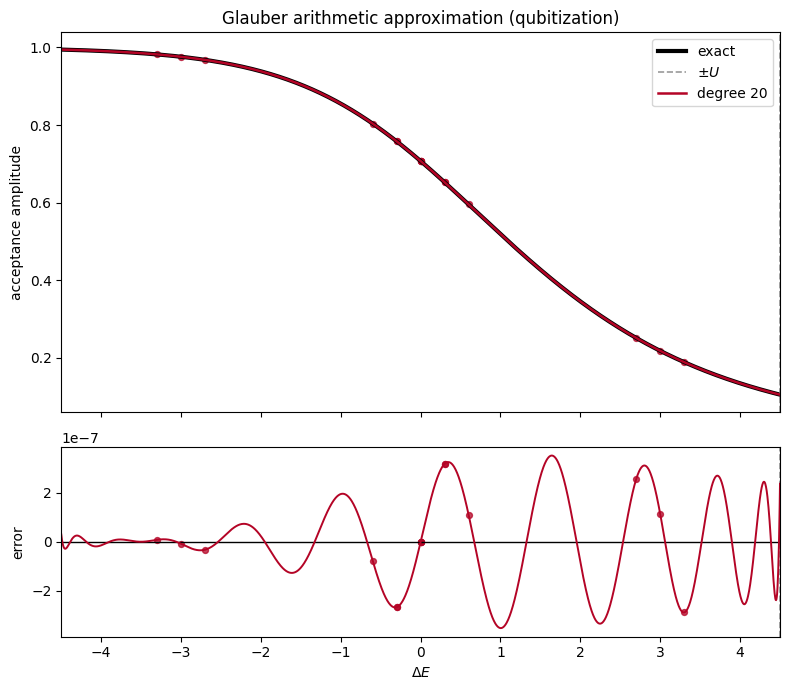

In [5]:
_ = show_approximation_and_error(h_single, J_single, beta=1.0, a=1, degs=[20], signal="qubitization")

The next plot checks the same point more directly. For each degree, we extract the circuit good-block amplitudes for all computational-basis pairs $(x,y)$ and compare them with the exact values. The maximum and mean absolute errors should decrease rapidly with the degree.


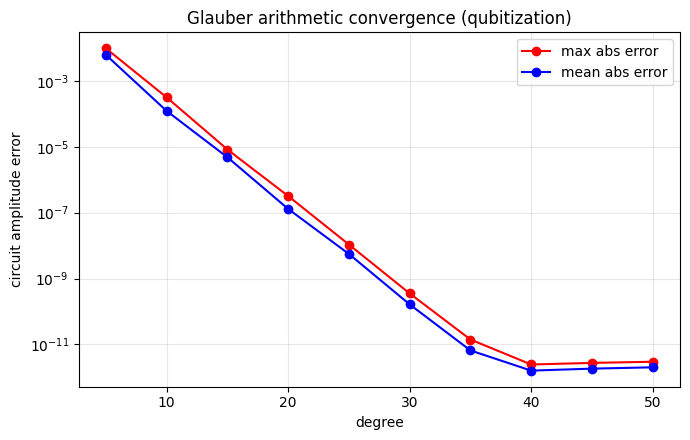

In [6]:
_ = show_degree_error_scaling(h_single, J_single, beta=1.0, a=1, degs=[5, 10, 15, 20, 25, 30, 35, 40, 45, 50], signal="qubitization")

We now repeat the same experiment with the Trotter phase signal. Here the product formula itself is exact because $H_\Delta$ is diagonal, but the signal variable is the wrapped phase $e^{-it\Delta E}$. Therefore the polynomial approximation is a Laurent/Fourier approximation in a periodic variable, not a Chebyshev approximation in the real energy variable.


20 Creating trotter coin...
20 Getting unitary with 9 qubits...
Actual: [ 0.   2.7 -0.3 -0.6 -2.7  0.  -3.  -3.3  0.3  3.   0.  -0.3  0.6  3.3
  0.3  0. ] => [0.70710679 0.25094299 0.75792331 0.80352374 0.96800332 0.70710679
 0.97600356 0.98204486 0.65234422 0.21777029 0.70710679 0.75792331
 0.59527142 0.18861175 0.65234422 0.70710679]
Expected polynomial: [ 0.   2.7 -0.3 -0.6 -2.7  0.  -3.  -3.3  0.3  3.   0.  -0.3  0.6  3.3
  0.3  0. ] => [0.70710679 0.25094299 0.75792331 0.80352374 0.96800332 0.70710679
 0.97600356 0.98204486 0.65234422 0.21777029 0.70710679 0.75792331
 0.59527142 0.18861175 0.65234422 0.70710679]
Exact: [ 0.   2.7 -0.3 -0.6 -2.7  0.  -3.  -3.3  0.3  3.   0.  -0.3  0.6  3.3
  0.3  0. ] => [0.70710678 0.25094493 0.75791986 0.80352741 0.96800137 0.70710678
 0.97599904 0.98205336 0.65234767 0.21777482 0.70710678 0.75791986
 0.59526775 0.18860326 0.65234767 0.70710678]


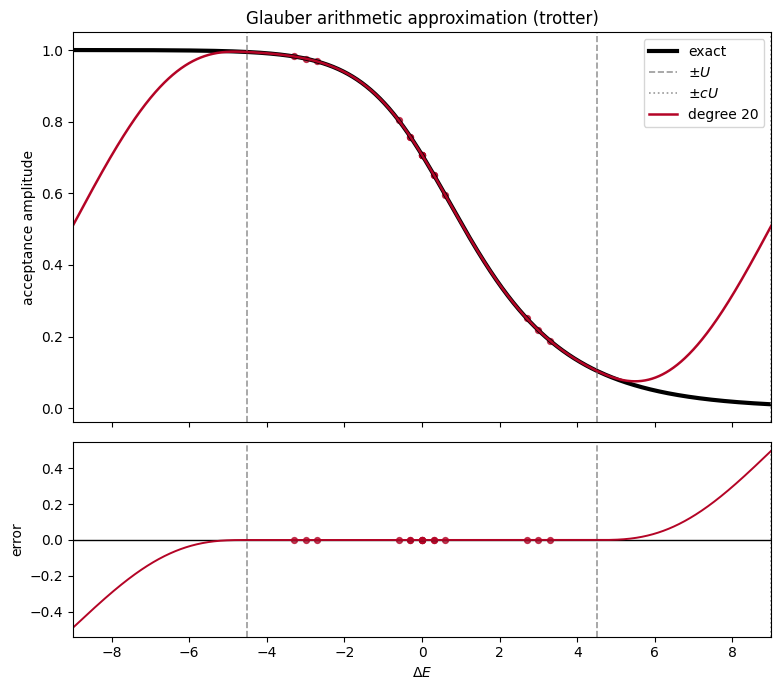

In [7]:
_ = show_approximation_and_error(h_single, J_single, beta=1.0, a=1, degs=[20], signal="trotter")

The degree-scaling plot for the Trotter signal usually behaves worse. This is not a Trotter error: it is an approximation-theoretic effect coming from the fact that a non-periodic function of $\Delta E$ is being approximated by a periodic function of $t\Delta E$.


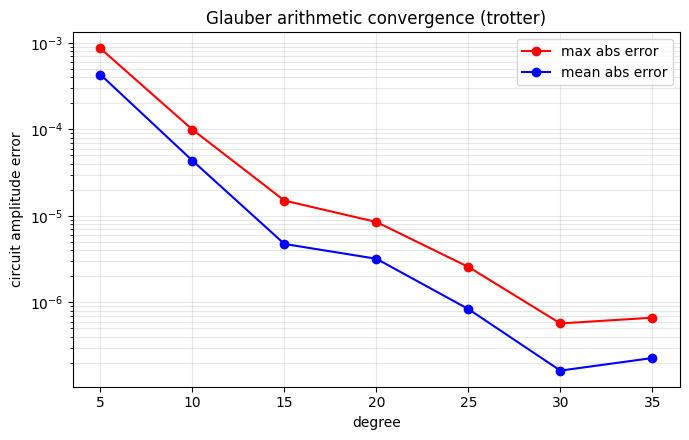

In [8]:
_ = show_degree_error_scaling(h_single, J_single, beta=1.0, a=1, degs=[5, 10, 15, 20, 25, 30, 35], signal="trotter")

### Numerical estimate of the necessary degree

For the qubitized signal, the expected model is approximately exponential in the degree. We fit the empirical maximum error to

$$
\varepsilon_{\max}(d) \approx 2^{b-cd}.
$$

The parameter $c$ is the empirical decay rate. The reported RMSE is measured in $\log_2$-error units, so an RMSE of $r$ means a typical multiplicative deviation of about $2^r$ from the fitted law.


In [9]:
def fit_single_exp_error_scaling(h_single, J_single, beta, a, degs, n_grid=1000, fit_tail_fraction=0.5):
    h_single = np.asarray(h_single, dtype=float)
    J_single = np.asarray(J_single, dtype=float)
    degs = np.array(sorted(degs), dtype=int)
    n = len(h_single)

    ref = GlauberArithmetic(n, h_single, J_single, beta=beta, eps=1e-2, a=a, signal="qubitization", mocked_circuit=True, mocked_angles=True)
    alpha = float(ref.alpha)

    delta_grid = alpha * np.linspace(-1.0, 1.0, n_grid)
    errors = []

    for d in degs:
        coin = GlauberArithmetic(n, h_single, J_single, beta=beta, eps=1e-2, a=a, signal="qubitization", degree=int(d), mocked_circuit=True, mocked_angles=True)
        approx = coin.evaluate_polynomial_delta(delta_grid)
        exact = coin.exact_amplitude(delta_grid)
        errors.append(float(np.max(np.abs(approx - exact))))

    errors = np.asarray(errors, dtype=float)
    log_errors = np.log2(np.maximum(errors, 1e-300))

    start = int((1.0 - fit_tail_fraction) * len(degs))
    fit_degs = degs[start:]
    fit_logs = log_errors[start:]

    slope, b = np.polyfit(fit_degs, fit_logs, deg=1)
    c = -float(slope)
    b = float(b)

    predicted_logs = b - c * fit_degs
    rmse = float(np.sqrt(np.mean((fit_logs - predicted_logs) ** 2)))

    return b, c, rmse


betas = [1.0, 10.0, 100.0]
a_values = [1.0, 10.0]
degs = [10, 20, 30, 40, 50]

print("Fit model: max_err(d) ≈ 2^(b - c d)")
print("RMSE is measured in log2(error) units.")
print()

for beta in betas:
    for a in a_values:
        b, c, rmse = fit_single_exp_error_scaling(h_single, J_single, beta=beta, a=a, degs=degs)
        print(f"beta = {beta:>6g}, a = {a:>6g} | b = {b:>10.5f}, c = {c:>10.5f}, RMSE = {rmse:>8.4f}, RMSE factor ≈ {2**rmse:>8.4f}")

Fit model: max_err(d) ≈ 2^(b - c d)
RMSE is measured in log2(error) units.

beta =      1, a =      1 | b =   -8.60364, c =    0.77066, RMSE =   0.8887, RMSE factor ≈   1.8514
beta =      1, a =     10 | b =  -22.75727, c =    0.50403, RMSE =   2.1400, RMSE factor ≈   4.4075
beta =     10, a =      1 | b =   -0.38028, c =    0.11451, RMSE =   0.0009, RMSE factor ≈   1.0006
beta =     10, a =     10 | b =   -3.91010, c =    0.11776, RMSE =   0.0031, RMSE factor ≈   1.0022
beta =    100, a =      1 | b =   -0.56465, c =    0.00949, RMSE =   0.0009, RMSE factor ≈   1.0007
beta =    100, a =     10 | b =   -1.28194, c =    0.04081, RMSE =   0.0764, RMSE factor ≈   1.0544


### Check correctness

Finally, we inspect one computational-basis input directly. We prepare a fixed pair $(x,y)$, apply the Glauber coin, and print the amplitude of the all-zero acceptance branch. The remaining printed amplitudes are the orthogonal bad branch for the same system state. Their squared norm should be $1-|g(x,y)|^2$, up to the polynomial approximation error.


In [10]:
def _bits_be(value, width):
    return np.array([int(c) for c in np.binary_repr(value, width=width)], dtype=int)


def _set_register(qc, qubits, bits):
    for q, bit in zip(qubits, bits):
        if int(bit): qc.x(int(q))


def _index_from_register(qubits, bits):
    return sum(int(bit) << int(q) for q, bit in zip(qubits, bits))


def _same_register(index, qubits, bits):
    return all(((index >> int(q)) & 1) == int(bit) for q, bit in zip(qubits, bits))


def _state_label(index, nqubits):
    return "|" + "".join(str((index >> q) & 1) for q in reversed(range(nqubits))) + ">"


def _ising_energy(value, h, J):
    bits = _bits_be(value, len(h))
    z = 1 - 2 * bits
    return float(np.dot(h, z) + sum(J[i, j] * z[i] * z[j] for i in range(len(h)) for j in range(i + 1, len(h))))


x, y = 1, 2
beta, a, degree = 1.0, 1.0, 20
coin = GlauberArithmetic(n, h_single, J_single, beta=beta, eps=1e-2, a=a, signal="qubitization", degree=degree, mocked_circuit=True, mocked_angles=False)

qc = QuantumCircuit(coin.num_qubits)
x_bits, y_bits = _bits_be(x, n), _bits_be(y, n)
_set_register(qc, coin.layout["A"], x_bits)
_set_register(qc, coin.layout["B"], y_bits)
qc.append(coin, range(coin.num_qubits))
state = Statevector.from_int(0, 2**coin.num_qubits).evolve(qc).data

good_index = _index_from_register(coin.layout["A"], x_bits) + _index_from_register(coin.layout["B"], y_bits)
realized = state[good_index]
delta = _ising_energy(y, h_single, J_single) - _ising_energy(x, h_single, J_single)
expected = (1.0 / (1.0 + np.exp(beta * delta))) ** (1.0 / (2.0 * a))
others = [(idx, amp) for idx, amp in enumerate(state) if idx != good_index and abs(amp) > 1e-8 and _same_register(idx, coin.layout["A"], x_bits) and _same_register(idx, coin.layout["B"], y_bits)]

print(f"x = {x}, y = {y}, DeltaE = {delta:.8f}")
print(f"acceptance amplitude, circuit = {realized:.12g}")
print(f"acceptance amplitude, exact   = {expected:.12g}")
print(f"acceptance probability        = {abs(realized)**2:.12g}")
print(f"bad-branch norm               = {np.sqrt(sum(abs(amp)**2 for _, amp in others)):.12g}")
print("nonzero amplitudes in the orthogonal branch, same x,y:")
for idx, amp in others[:10]: print(f"  {_state_label(idx, coin.num_qubits)}: {amp:.12g}")


x = 1, y = 2, DeltaE = -3.00000000
acceptance amplitude, circuit = 0.975999031884-1.07160424606e-14j
acceptance amplitude, exact   = 0.97599904038
acceptance probability        = 0.952574110238
bad-branch norm               = 0.217774860257
nonzero amplitudes in the orthogonal branch, same x,y:
  |00001101>: 0.150895866147-1.06042731768e-15j
  |00101101>: -2.32141962522e-16-0.0702229696602j
  |10001101>: -0.0993102760836+9.17389028903e-16j
  |10101101>: -1.31410977954e-15-0.0993102760836j


## Behaviour of Metropolis-Hastings acceptance

For the Metropolis-Hastings rule, we do not approximate the kink at $\Delta E=0$ directly. Instead, the implementation separates the non-smooth clipping from the smooth exponential. The `MetropolisHastingsEnergy` gate is the classical reversible part: it computes a fixed-point, shifted, clipped energy signal that can later be passed to the square-root exponential block.


In [11]:
from monaqa2.qiskit.metropolis_hastings_energy_gate import MetropolisHastingsEnergy

The precision parameter `eps` is the budget for the fixed-point energy arithmetic only. The implementation first upper-bounds the absolute energy difference by $U=2(\sum_i |h_i|+\sum_{i<j}|J_{ij}|)$ and rescales the requested absolute precision to `scaled_eps = eps / U`. It then chooses

$$
f=\left\lceil \log_2\left(\frac{n(n+1)}{\mathrm{scaled\_eps}^2}\right)\right\rceil
$$

fractional bits and sets the normalization to $D=U/(2-2^{-f})$. The output signal is a Q1.$f$ two's-complement register encoding the shifted clipped value $(1-2^{-f})+\min(0,\Delta E/D)$.


In [12]:
def _flatten_to_classical_circuit(obj):
    circ = obj if isinstance(obj, QuantumCircuit) else obj.definition
    out = QuantumCircuit(circ.num_qubits)

    def inline_into(dst, src, qmap):
        for inst in src.data:
            name = inst.operation.name
            local = [src.find_bit(q).index for q in inst.qubits]
            mapped = [qmap[i] for i in local]
            if name == "x": dst.x(mapped[0])
            elif name == "cx": dst.cx(mapped[0], mapped[1])
            elif name == "ccx": dst.ccx(mapped[0], mapped[1], mapped[2])
            else: inline_into(dst, inst.operation.definition, mapped)

    inline_into(out, circ, list(range(circ.num_qubits)))
    return out


def _apply_classical_circuit(qc, bits):
    state = bits[:]
    for inst in qc.data:
        name = inst.operation.name
        qargs = [qc.find_bit(q).index for q in inst.qubits]
        if name == "x": state[qargs[0]] ^= 1
        elif name == "cx" and state[qargs[0]]: state[qargs[1]] ^= 1
        elif name == "ccx" and state[qargs[0]] and state[qargs[1]]: state[qargs[2]] ^= 1
    return state


def _bits_le(value, width):
    return [(value >> i) & 1 for i in range(width)]


def _bits_from_scaled(scaled, width):
    return [(scaled % (1 << width) >> j) & 1 for j in range(width)]


def _scaled_normalized_energy_diff(gate, x_bits, y_bits):
    total = 0
    for term in gate.terms:
        bits = x_bits if term["side"] == "A" else y_bits
        active = bits[term["idxs"][0]] == 1 if term["arity"] == 1 else bits[term["idxs"][0]] == 1 and bits[term["idxs"][1]] == 1
        if active: total += term["scaled"]
    return total


def _expected_mh_energy_outputs(gate, x_bits, y_bits):
    raw_scaled = _scaled_normalized_energy_diff(gate, x_bits, y_bits)
    clipped_scaled = min(0, raw_scaled)
    shifted_scaled = clipped_scaled + (1 << gate.fractional_bits) - 1
    wide_bits = _bits_from_scaled(shifted_scaled, gate.acc_word_bits)
    signal_bits = wide_bits[: gate.fractional_bits] + [wide_bits[-1]]
    return raw_scaled, clipped_scaled, shifted_scaled, wide_bits, signal_bits


mh_eps = 0.25
mh_energy = MetropolisHastingsEnergy(n, h_single, J_single, mh_eps)
flat = _flatten_to_classical_circuit(mh_energy)

x, y = 1, 2
x_bits, y_bits = _bits_le(x, mh_energy.n), _bits_le(y, mh_energy.n)
input_bits = x_bits + y_bits + [0] * (mh_energy.num_qubits - 2 * mh_energy.n)
actual = _apply_classical_circuit(flat, input_bits)
raw_scaled, clipped_scaled, shifted_scaled, expected_wide, expected_signal = _expected_mh_energy_outputs(mh_energy, x_bits, y_bits)
output_wide, signal = mh_energy.layout["output_wide"], mh_energy.layout["signal"]
non_output_aux = [q for q in range(2 * mh_energy.n, mh_energy.num_qubits) if q not in set(output_wide) | set(signal)]

print(f"fractional bits f = {mh_energy.fractional_bits}")
print(f"normalization D   = {mh_energy.normalization:.12g}")
print(f"raw scaled        = {raw_scaled}")
print(f"clipped scaled    = {clipped_scaled}")
print(f"shifted scaled    = {shifted_scaled}")
print(f"A preserved       = {actual[:mh_energy.n] == x_bits}")
print(f"B preserved       = {actual[mh_energy.n:2 * mh_energy.n] == y_bits}")
print(f"work reset        = {all(actual[q] == 0 for q in non_output_aux)}")
print(f"output_wide bits  = {[actual[q] for q in output_wide]} expected {expected_wide}")
print(f"signal bits       = {[actual[q] for q in signal]} expected {expected_signal}")


fractional bits f = 11
normalization D   = 2.25054945055
raw scaled        = -1365
clipped scaled    = -1365
shifted scaled    = 682
A preserved       = True
B preserved       = True
work reset        = True
output_wide bits  = [0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0] expected [0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0]
signal bits       = [0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0] expected [0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0]


The second part of the hybrid construction is the smooth square-root exponential. The `SqrtExpArithmetic` gate acts only on the fixed-point signal register. It uses qubitization/GQSP to implement the diagonal amplitude associated with $\exp(\beta D(H_z-\mathrm{shift}))$, where $D$ is the normalization produced by the fixed-point block.


In [13]:
from monaqa2.qiskit.sqrt_exp_arithmetic_gate import SqrtExpArithmetic

The next cell checks two things. First, it evaluates the scalar Laurent/Bessel approximation used by `SqrtExpArithmetic` and shows that the maximum error decreases rapidly as the automatically selected degree increases. Second, it applies the actual unitary to one computational-basis signal state and compares the good-branch amplitude with the expected scalar target.


In [14]:
def _sqrt_exp_hz_from_bits(bits):
    z = 1 - 2 * np.asarray(bits, dtype=int)
    return float(0.5 * z[-1] - sum((2.0 ** (j - len(bits))) * z[j] for j in range(len(bits) - 1)))


def _sqrt_exp_target(gate, basis_index):
    bits = _bits_be(basis_index, gate.b)
    return float(np.exp(gate.beta * gate.normalization * (_sqrt_exp_hz_from_bits(bits) - gate._shift())))


def _sqrt_exp_poly_error(gate, n_grid=2000):
    alpha = gate._alpha_signal()
    x_grid = alpha * np.linspace(-1.0, 1.0, n_grid)
    theta = np.arccos(np.clip(x_grid / alpha, -1.0, 1.0))
    powers = np.arange(-gate.degree, gate.degree + 1)
    approx = np.sum(gate.poly_coeffs[:, None] * np.exp(1j * powers[:, None] * theta[None, :]), axis=0).real
    exact = np.exp(gate.beta * gate.normalization * (x_grid - gate._shift()))
    return float(np.max(np.abs(approx - exact)))


b, beta, normalization = 3, 1.0, mh_energy.normalization
print("Scalar approximation error:")
for eps in [1e-1, 1e-2, 1e-3, 1e-4, 1e-5]:
    sqrt_exp = SqrtExpArithmetic(b, beta, normalization, eps, mocked_circuit=True, mocked_angles=True)
    print(f"eps = {eps:>7g}, degree = {sqrt_exp.degree:>3d}, max scalar error = {_sqrt_exp_poly_error(sqrt_exp):.3e}")

basis_index = 3
sqrt_exp = SqrtExpArithmetic(b, beta, normalization, 1e-4, mocked_circuit=True, mocked_angles=False)
bits = _bits_be(basis_index, b)
qc = QuantumCircuit(sqrt_exp.num_qubits)
_set_register(qc, sqrt_exp.layout["signal"], bits)
qc.append(sqrt_exp, range(sqrt_exp.num_qubits))
state = Statevector.from_int(0, 2**sqrt_exp.num_qubits).evolve(qc).data

good_index = _index_from_register(sqrt_exp.layout["signal"], bits)
realized = state[good_index]
expected = _sqrt_exp_target(sqrt_exp, basis_index)
others = [(idx, amp) for idx, amp in enumerate(state) if idx != good_index and abs(amp) > 1e-8 and _same_register(idx, sqrt_exp.layout["signal"], bits)]

print("\nBasis-state amplitude check:")
print(f"signal basis index         = {basis_index}, bits = {bits.tolist()}")
print(f"acceptance amplitude, circuit = {realized:.12g}")
print(f"acceptance amplitude, exact   = {expected:.12g}")
print(f"bad-branch norm               = {np.sqrt(sum(abs(amp)**2 for _, amp in others)):.12g}")
print("nonzero amplitudes in the orthogonal branch, same signal:")
for idx, amp in others[:10]: print(f"  {_state_label(idx, sqrt_exp.num_qubits)}: {amp:.12g}")


Scalar approximation error:
eps =     0.1, degree =  11, max scalar error = 1.828e-10
eps =    0.01, degree =  13, max scalar error = 9.542e-13
eps =   0.001, degree =  15, max scalar error = 3.941e-15
eps =  0.0001, degree =  17, max scalar error = 2.220e-16
eps =   1e-05, degree =  20, max scalar error = 2.220e-16

Basis-state amplitude check:
signal basis index         = 3, bits = [0, 1, 1]
acceptance amplitude, circuit = 0.0194781581032-1.88831989929e-16j
acceptance amplitude, exact   = 0.0194781581032
bad-branch norm               = 0.999810282682
nonzero amplitudes in the orthogonal branch, same signal:
  |001101>: -0.950236602947+6.76142560513e-15j
  |011101>: -2.91749347263e-16-0.139047473746j
  |101101>: 0.227063573801-1.77518504845e-15j
  |111101>: 1.18482996979e-15+0.160558192795j
